# Results Analysis — PaySim (Synthetic Mobile-Money) Fraud Track

**Dissertation:** Graph Neural Networks for Systemic Risk and Fraud Detection in Credit Systems
**Track:** Fraud / systemic risk (graph-based)
**Student:** Chandan Nagavolu — M.Tech, BITS Pilani WILP

This notebook reads the cross-model results table (`reports/results_paysim.csv`)
and the credit-scorecard KS/Gini outputs (`reports/ks_gini/`) produced by the
training and evaluation scripts, and turns them into the figures and the
interpretation that feed the dissertation's **Testing** chapter.

It covers four questions specific to PaySim:

1. **Leaderboard** — which model best separates fraud on the held-out test set?
2. **Leakage ablation** — what happens when the engineered balance-consistency
   features (which encode PaySim's deterministic fraud rule) are removed?
3. **KS / Gini scorecard** — the credit-industry discrimination view, and why
   the decile KS *saturates* under 0.13% fraud prevalence.
4. **Full picture** — a single heatmap of every metric for every model.

> *Notebooks are for exploration and narrative only; all reusable logic lives
> in `src/` per the project conventions.*

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110


def find_project_root(start: Path) -> Path:
    """Walk up from the notebook until the folder containing CLAUDE.md."""
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / "CLAUDE.md").exists():
            return parent
    raise FileNotFoundError("Could not locate project root (CLAUDE.md).")


ROOT = find_project_root(Path.cwd())
RESULTS_CSV = ROOT / "reports" / "results_paysim.csv"
KS_DIR = ROOT / "reports" / "ks_gini"
KS_SUMMARY = KS_DIR / "ks_gini_summary.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Results CSV :", RESULTS_CSV, "->", "found" if RESULTS_CSV.exists() else "MISSING")
print("KS summary  :", KS_SUMMARY, "->", "found" if KS_SUMMARY.exists() else "MISSING")
print("Figures dir :", FIG_DIR)

Project root: C:\Users\achal\OneDrive\Documents\MTech_Chandan\4Sem\ProjectWork
Results CSV : C:\Users\achal\OneDrive\Documents\MTech_Chandan\4Sem\ProjectWork\reports\results_paysim.csv -> found
KS summary  : C:\Users\achal\OneDrive\Documents\MTech_Chandan\4Sem\ProjectWork\reports\ks_gini\ks_gini_summary.csv -> found
Figures dir : C:\Users\achal\OneDrive\Documents\MTech_Chandan\4Sem\ProjectWork\reports\figures


## 1. Why these metrics?

PaySim is **extremely imbalanced** — only **~0.13%** of transactions are fraud
(vs ~3.5% on IEEE-CIS). A model that predicts "never fraud" already scores
99.87% accuracy, so **accuracy is meaningless** and we rely on imbalance-aware
and credit-industry metrics:

| Metric | Family | Why it matters here |
|---|---|---|
| **PR-AUC** (average precision) | Fraud | Area under the precision–recall curve — focuses on the rare fraud class; the headline metric for imbalanced detection. |
| **MCC** | Fraud | Balanced single number using all four confusion-matrix cells; robust to imbalance, ranges −1…+1. |
| **ROC-AUC** | Standard | Overall ranking quality across thresholds. |
| **KS statistic** | Credit | Max separation of good/bad score distributions. Rule of thumb: **KS > 0.40 = strong** — but see §3 for why it *saturates* at this prevalence. |
| **Gini** | Credit | `2·AUC − 1`; rank-ordering power on a 0–1 scale risk teams expect. |
| **F1 / Precision / Recall** | Standard | Threshold-0.5 operating point. |

All are computed by the shared `src/evaluation/metrics.py::compute_all_metrics`
(and the decile KS/Gini by `src/evaluation/ks_gini.py`), so baseline, GNN, and
future temporal/autoencoder models are scored identically.

In [2]:
raw = pd.read_csv(RESULTS_CSV, parse_dates=["timestamp"])
raw = raw.sort_values("timestamp").reset_index(drop=True)

# PaySim's second axis is feature_set (full | no_leakage) rather than the
# resampling axis used on IEEE-CIS. Keep the LATEST row per
# (model, feature_set, split) for the current view.
latest = (
    raw.groupby(["model", "feature_set", "split"], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

METRICS = ["pr_auc", "roc_auc", "f1", "mcc", "ks_statistic", "gini"]
PRETTY = {"pr_auc": "PR-AUC", "roc_auc": "ROC-AUC", "f1": "F1",
          "mcc": "MCC", "ks_statistic": "KS", "gini": "Gini"}
MODEL_PRETTY = {"logistic_regression": "Logistic Reg.", "random_forest": "Random Forest",
                "xgboost": "XGBoost", "hetero_sage": "GNN (HeteroSAGE)"}
MODEL_ORDER = ["logistic_regression", "random_forest", "xgboost", "hetero_sage"]
PALETTE = dict(zip(MODEL_ORDER, sns.color_palette("Set2", len(MODEL_ORDER))))
FRAUD_RATE = 0.00129  # ~0.13% positives -> random-ranker PR-AUC reference

print(f"{len(raw)} total rows, {len(latest)} after keeping latest per group.")
latest[["model", "feature_set", "split", "n_features", *METRICS]]

14 total rows, 14 after keeping latest per group.


,model,feature_set,split,n_features,pr_auc,roc_auc,f1,mcc,ks_statistic,gini
0,logistic_regression,full,val,16,0.741342,0.990171,0.015560,0.080456,0.972207,0.980343
1,logistic_regression,full,test,16,0.748395,0.997830,0.015822,0.081533,0.976626,0.995659
2,random_forest,full,val,16,0.994679,0.999560,0.997290,0.997290,0.994595,0.999119
3,random_forest,full,test,16,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,xgboost,full,val,16,0.990489,0.999969,0.951613,0.951564,0.995754,0.999938
5,xgboost,full,test,16,0.994693,0.999993,0.937824,0.938549,0.999790,0.999985
6,logistic_regression,no_leakage,val,12,0.625612,0.989493,0.008784,0.055458,0.930472,0.978986
7,logistic_regression,no_leakage,test,12,0.571380,0.994787,0.008900,0.056406,0.943399,0.989574
8,random_forest,no_leakage,val,12,0.865208,0.996793,0.312221,0.419283,0.951504,0.993587
9,random_forest,no_leakage,test,12,0.862240,0.998738,0.313406,0.418302,0.972044,0.997476


## 2. Model leaderboard — held-out test set (full feature set)

The full feature set includes the engineered balance-consistency features
(`errorBalanceOrig/Dest`, `balanceDeltaOrig/Dest`). The GNN was trained on this
graph, so the full-feature test split is the only place all four models appear
together. **Read the tree models here with caution** — §2's discussion and the
§3 ablation show how much of their score is a leakage artefact.

In [3]:
board = (
    latest[(latest.split == "test") & (latest.feature_set == "full")]
    .set_index("model")
    .reindex(MODEL_ORDER)
)

table = board[METRICS].rename(columns=PRETTY)
table.index = [MODEL_PRETTY[m] for m in table.index]
table.round(4)

,PR-AUC,ROC-AUC,F1,MCC,KS,Gini
Logistic Reg.,0.7484,0.9978,0.0158,0.0815,0.9766,0.9957
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,0.9947,1.0000,0.9378,0.9385,0.9998,1.0000
GNN (HeteroSAGE),0.5357,0.9560,0.4897,0.4895,0.8037,0.9119


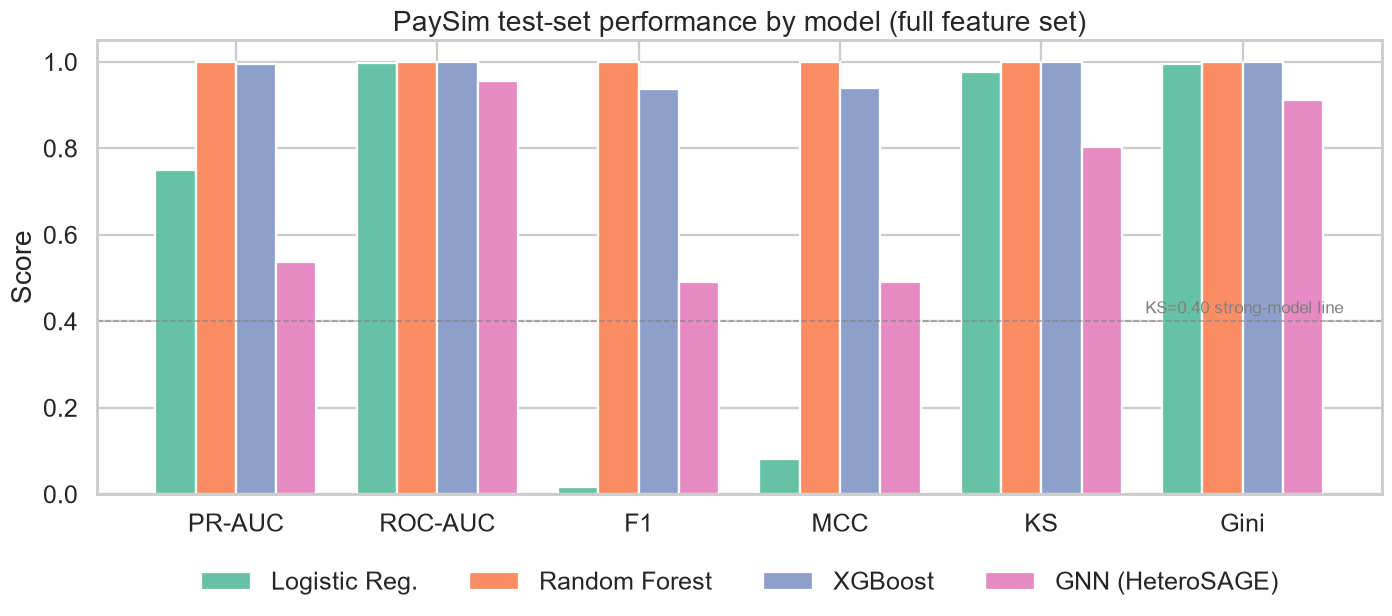

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(METRICS))
width = 0.2

for i, model in enumerate(MODEL_ORDER):
    vals = board.loc[model, METRICS].values.astype(float)
    ax.bar(x + (i - 1.5) * width, vals, width,
           label=MODEL_PRETTY[model], color=PALETTE[model], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("PaySim test-set performance by model (full feature set)")
ax.axhline(0.40, ls="--", lw=1, color="grey", alpha=0.7)
ax.text(len(METRICS) - 0.5, 0.41, "KS=0.40 strong-model line", ha="right",
        va="bottom", fontsize=11, color="grey")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
fig.savefig(FIG_DIR / "paysim_leaderboard_full_test.png", bbox_inches="tight")
plt.show()

### Reading the full-feature leaderboard

- **Random Forest and XGBoost look near-perfect** (PR-AUC ≈ 1.0, Gini ≈ 1.0).
  This is **not** a genuine result: PaySim's synthetic fraud deterministically
  drains the origin account, and the engineered `errorBalance*` features encode
  that rule almost exactly — the trees memorise it. We strip those features in §3.
- **The GNN (HeteroSAGE)** scores far lower (PR-AUC ≈ 0.54, Gini ≈ 0.91) *despite*
  having the same leaky features available — message passing dilutes the sharp
  per-transaction balance signal that trees exploit directly.
- **Logistic Regression** has a high ROC-AUC/Gini but PR-AUC ≈ 0.75 with tiny
  precision: class-weighting drives recall ≈ 1.0 at the cost of many false alarms.

## 3. Leakage ablation — full vs no-leakage features

The honest benchmark removes the four engineered balance-consistency features
(`features.leakage_cols`) and keeps only legitimate, production-available signals
(including the raw before/after balances). This is run via
`train_baseline_paysim.py --no-leakage`. The plot contrasts the two feature sets
on the test split for the three baselines.

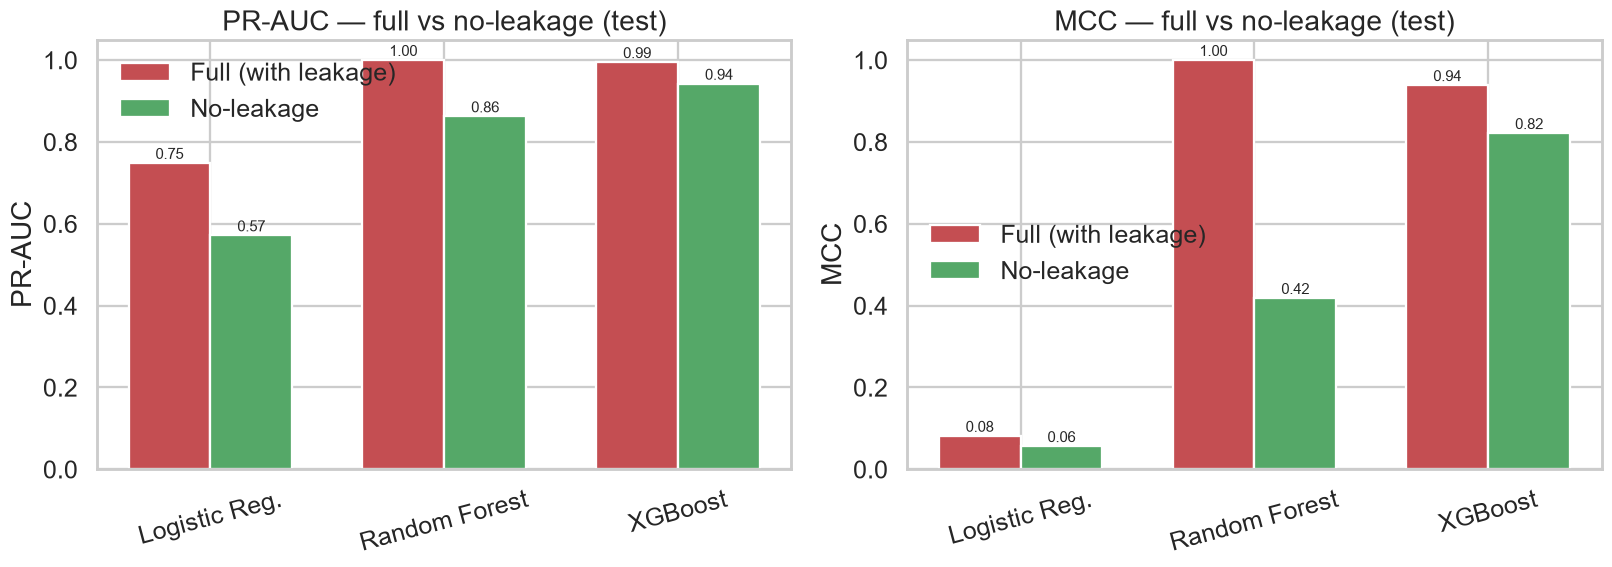

In [5]:
baselines = ["logistic_regression", "random_forest", "xgboost"]
test = latest[latest.split == "test"]

full_df = test[test.feature_set == "full"].set_index("model").reindex(baselines)
noleak_df = test[test.feature_set == "no_leakage"].set_index("model").reindex(baselines)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
w = 0.35

# (a) PR-AUC: full vs no-leakage
ax = axes[0]
x = np.arange(len(baselines))
ax.bar(x - w / 2, full_df["pr_auc"].values, w, label="Full (with leakage)", color="#C44E52")
ax.bar(x + w / 2, noleak_df["pr_auc"].values, w, label="No-leakage", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels([MODEL_PRETTY[m] for m in baselines], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_title("PR-AUC — full vs no-leakage (test)")
ax.set_ylabel("PR-AUC")
ax.legend(frameon=False)
for i, m in enumerate(baselines):
    ax.text(i - w / 2, full_df.loc[m, "pr_auc"] + 0.01, f"{full_df.loc[m, 'pr_auc']:.2f}", ha="center", fontsize=10)
    ax.text(i + w / 2, noleak_df.loc[m, "pr_auc"] + 0.01, f"{noleak_df.loc[m, 'pr_auc']:.2f}", ha="center", fontsize=10)

# (b) MCC: full vs no-leakage
ax = axes[1]
ax.bar(x - w / 2, full_df["mcc"].values, w, label="Full (with leakage)", color="#C44E52")
ax.bar(x + w / 2, noleak_df["mcc"].values, w, label="No-leakage", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels([MODEL_PRETTY[m] for m in baselines], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_title("MCC — full vs no-leakage (test)")
ax.set_ylabel("MCC")
ax.legend(frameon=False)
for i, m in enumerate(baselines):
    ax.text(i - w / 2, full_df.loc[m, "mcc"] + 0.01, f"{full_df.loc[m, 'mcc']:.2f}", ha="center", fontsize=10)
    ax.text(i + w / 2, noleak_df.loc[m, "mcc"] + 0.01, f"{noleak_df.loc[m, 'mcc']:.2f}", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(FIG_DIR / "paysim_leakage_ablation.png", bbox_inches="tight")
plt.show()

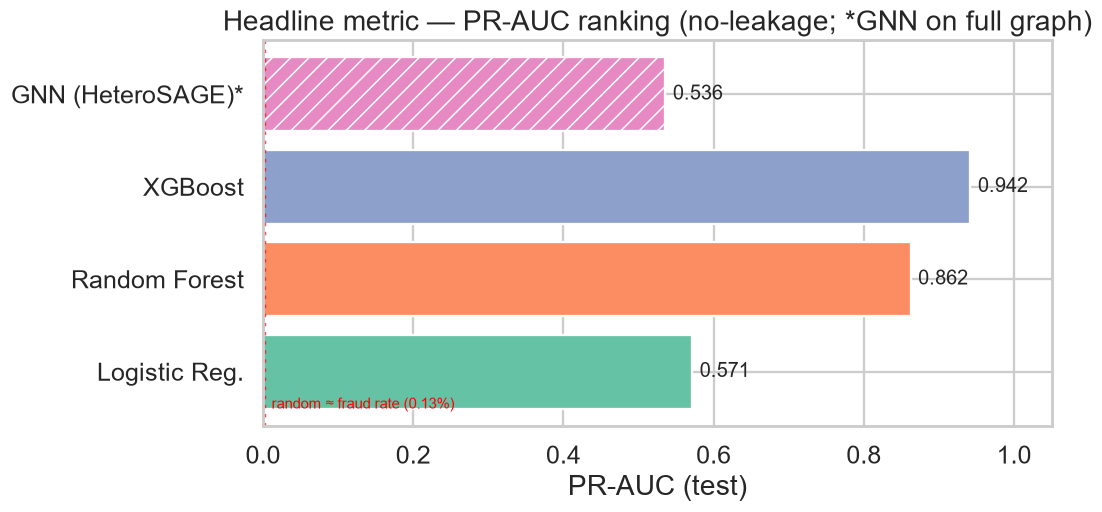

In [6]:
# Honest PR-AUC ranking (no-leakage). The GNN only exists on the full graph,
# so it is shown for reference with a hatch to flag the different feature set.
fig, ax = plt.subplots(figsize=(10, 5))
pr = noleak_df["pr_auc"].astype(float).sort_values()
bars = ax.barh([MODEL_PRETTY[m] for m in pr.index], pr.values,
               color=[PALETTE[m] for m in pr.index], edgecolor="white")
for b, v in zip(bars, pr.values):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center", fontsize=13)

# GNN reference (full-feature)
gnn_pr = float(board.loc["hetero_sage", "pr_auc"])
ax.barh("GNN (HeteroSAGE)*", gnn_pr, color=PALETTE["hetero_sage"], edgecolor="white", hatch="//")
ax.text(gnn_pr + 0.01, 3, f"{gnn_pr:.3f}", va="center", fontsize=13)

ax.set_xlim(0, 1.05)
ax.set_xlabel("PR-AUC (test)")
ax.set_title("Headline metric — PR-AUC ranking (no-leakage; *GNN on full graph)")
ax.axvline(FRAUD_RATE, ls=":", color="red", alpha=0.7)
ax.text(FRAUD_RATE + 0.01, -0.4, "random ≈ fraud rate (0.13%)", color="red", fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / "paysim_pr_auc_ranking.png", bbox_inches="tight")
plt.show()

### Reading the leakage ablation

- **The "perfect" tree scores collapse once the engineered balance features are
  removed.** Random Forest PR-AUC falls 1.00 → 0.86 and MCC 1.00 → 0.42; its
  precision crashes to ~0.19 (≈ 5 false alarms per true fraud). That confirms the
  full-feature result was a synthetic-data artefact.
- **XGBoost degrades gracefully** (PR-AUC 0.99 → 0.94, MCC 0.94 → 0.82) — relying
  on broader signal, not one giveaway feature. It is the **honest headline baseline**.
- **There is now real headroom for the GNN** (PR-AUC ≈ 0.54): with a degenerate
  1.00 baseline the relational model had nothing to demonstrate; the no-leakage
  setting is the fair comparison, though the GNN still trails the trees on PaySim.

## 4. KS statistic & Gini — the credit-scorecard view

`src/evaluation/evaluate_paysim_ks_gini.py` builds the decile (score-band) KS
table that risk teams report. Two KS flavours are compared:

- **KS (decile)** — rank into 10 equal-frequency bands, max gap between cumulative
  %bad and %good.
- **KS (continuous)** — max gap of the ROC tpr/fpr curves over all thresholds.

The bar chart and capture curves below show why the **decile KS saturates** at
this prevalence while continuous KS and Gini still discriminate.

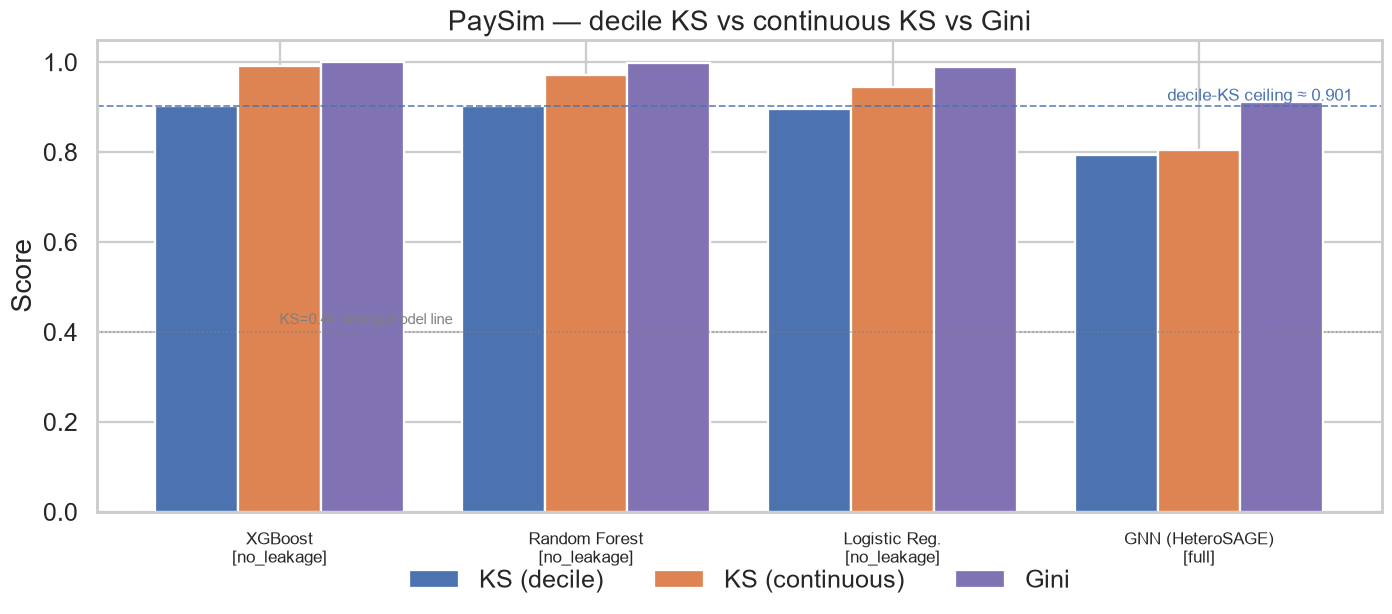

,model,feature_set,gini,ks_decile,ks_continuous,ks_peak_band
0,xgboost,no_leakage,0.9995,0.9012,0.9910,1
1,random_forest,no_leakage,0.9975,0.9012,0.9720,1
2,logistic_regression,no_leakage,0.9896,0.8958,0.9434,1
3,hetero_sage,full,0.9119,0.7929,0.8037,1


In [7]:
ks = pd.read_csv(KS_SUMMARY)

# Show the no-leakage baselines + the (full) GNN — the honest set.
sel = ks[((ks.feature_set == "no_leakage") & (ks.model.isin(baselines))) |
         (ks.model == "hetero_sage")].copy()
sel["label"] = sel.apply(lambda r: f"{MODEL_PRETTY[r['model']]}\n[{r['feature_set']}]", axis=1)
sel = sel.sort_values("ks_continuous", ascending=False).reset_index(drop=True)

ceiling = float(ks["ks_decile"].max())  # structural decile-KS ceiling at this prevalence

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(sel))
w = 0.27
ax.bar(x - w, sel["ks_decile"], w, label="KS (decile)", color="#4C72B0")
ax.bar(x, sel["ks_continuous"], w, label="KS (continuous)", color="#DD8452")
ax.bar(x + w, sel["gini"], w, label="Gini", color="#8172B3")
ax.axhline(ceiling, ls="--", lw=1.2, color="#4C72B0", alpha=0.8)
ax.text(len(sel) - 0.5, ceiling + 0.005, f"decile-KS ceiling ≈ {ceiling:.3f}",
        ha="right", va="bottom", fontsize=11, color="#4C72B0")
ax.axhline(0.40, ls=":", lw=1, color="grey", alpha=0.7)
ax.text(0, 0.41, "KS=0.40 strong-model line", va="bottom", fontsize=10, color="grey")
ax.set_xticks(x)
ax.set_xticklabels(sel["label"], fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("PaySim — decile KS vs continuous KS vs Gini")
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.22))
plt.tight_layout()
fig.savefig(FIG_DIR / "paysim_ks_gini_comparison.png", bbox_inches="tight")
plt.show()
sel[["model", "feature_set", "gini", "ks_decile", "ks_continuous", "ks_peak_band"]].round(4)

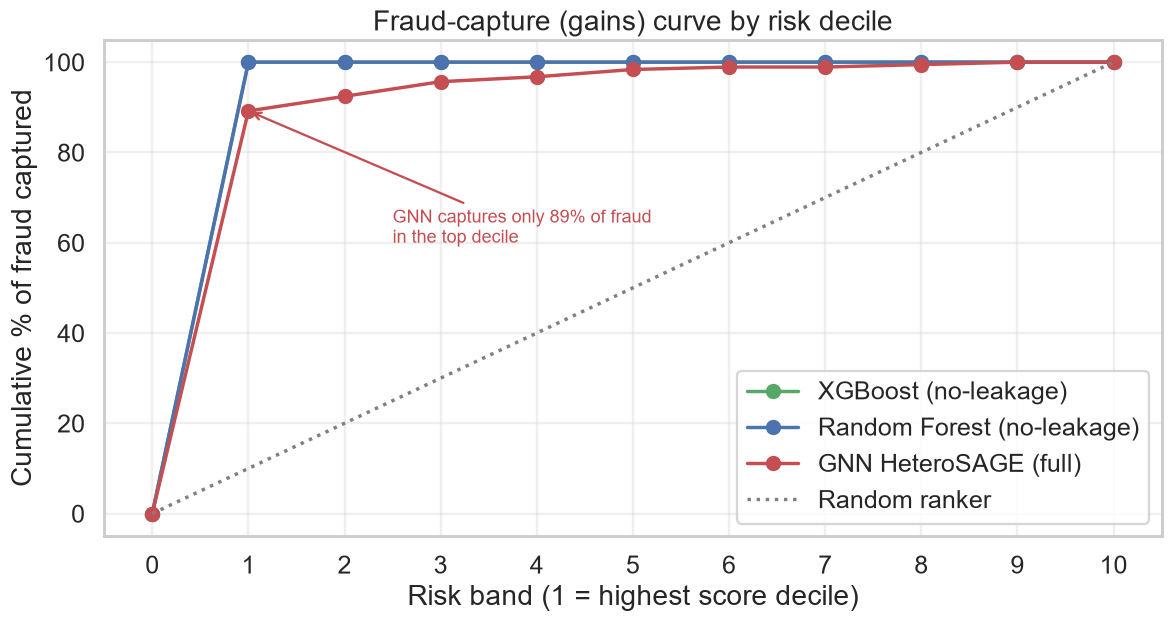

In [8]:
# Cumulative fraud-capture curves from the saved decile tables.
def load_ks_table(model, fset):
    return pd.read_csv(KS_DIR / f"{model}_{fset}_ks_table.csv")

curves = [
    ("xgboost", "no_leakage", "XGBoost (no-leakage)", "#55A868"),
    ("random_forest", "no_leakage", "Random Forest (no-leakage)", "#4C72B0"),
    ("hetero_sage", "full", "GNN HeteroSAGE (full)", "#C44E52"),
]

fig, ax = plt.subplots(figsize=(11, 6))
for model, fset, label, color in curves:
    t = load_ks_table(model, fset)
    x = np.concatenate([[0], t["band"].to_numpy()])
    cum_bad = np.concatenate([[0.0], t["cum_bad_pct"].to_numpy() * 100])
    ax.plot(x, cum_bad, marker="o", color=color, label=label)

# Diagonal = random ranker
ax.plot([0, 10], [0, 100], ls=":", color="grey", label="Random ranker")
ax.set_xlabel("Risk band (1 = highest score decile)")
ax.set_ylabel("Cumulative % of fraud captured")
ax.set_title("Fraud-capture (gains) curve by risk decile")
ax.set_xticks(range(0, 11))
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
# Annotate the GNN's top-decile gap
gnn_top = load_ks_table("hetero_sage", "full")["cum_bad_pct"].iloc[0] * 100
ax.annotate(f"GNN captures only {gnn_top:.0f}% of fraud\nin the top decile",
            xy=(1, gnn_top), xytext=(2.5, 60),
            arrowprops=dict(arrowstyle="->", color="#C44E52"), color="#C44E52", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "paysim_fraud_capture_curve.png", bbox_inches="tight")
plt.show()

### Reading the KS / Gini analysis

- **The decile KS saturates at ~0.90 — a structural ceiling, not model quality.**
  At 0.13% prevalence the top decile (10% of cases) trivially contains every
  fraud, so any model that ranks all frauds into band 1 reads KS ≈ 1.0 − 0.099 ≈
  0.901. The decile KS therefore *cannot* separate the strong tabular models.
- **Continuous KS and Gini still discriminate**, agreeing with PR-AUC/MCC:
  no-leakage XGBoost leads (Gini ≈ 0.9995), the GNN trails (Gini ≈ 0.91).
- **The GNN is the only model below the ceiling** (decile KS ≈ 0.79): its
  capture curve shows the top decile holds just ~89% of frauds — ~20 frauds leak
  into lower bands, an interpretable view of its weaker ranking.
- **Every model clears the KS > 0.40 "strong" rule of thumb**, but that rule
  assumes roughly balanced populations; at 0.13% prevalence the decile KS is
  inflated, so PR-AUC and MCC remain the deciding fraud metrics.

## 5. Full metric heatmap

Every current (latest) configuration on the test split, across all metrics — the
compact view for the dissertation's results table.

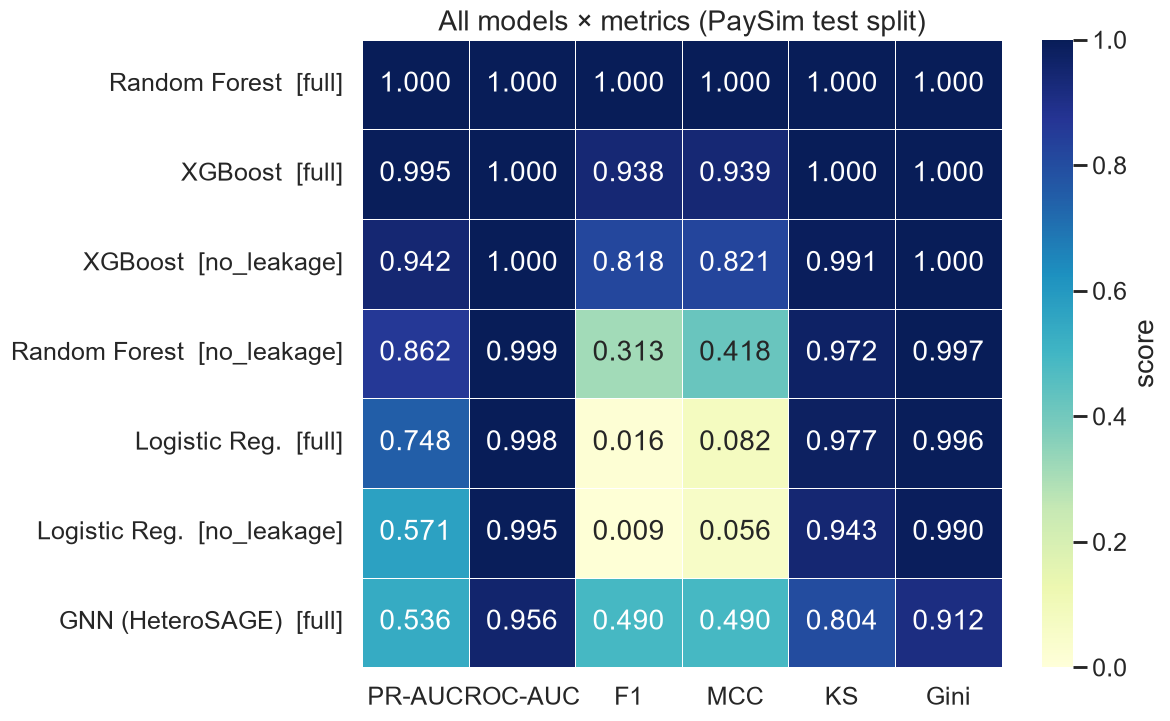

In [9]:
hm = (
    latest[latest.split == "test"]
    .assign(config=lambda d: d.model.map(MODEL_PRETTY) + "  [" + d.feature_set + "]")
    .set_index("config")[METRICS]
    .rename(columns=PRETTY)
    .sort_values("PR-AUC", ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 0.7 * len(hm) + 2))
sns.heatmap(hm, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={"label": "score"}, ax=ax)
ax.set_title("All models × metrics (PaySim test split)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIG_DIR / "paysim_metric_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Key findings

1. **PaySim is trivially separable with the engineered balance features** — the
   trees hit PR-AUC/Gini ≈ 1.0 by memorising the simulator's deterministic fraud
   rule. This is a documented **synthetic-data leakage artefact**, not a result.
2. **Under the honest no-leakage benchmark, XGBoost is the strongest model**
   (PR-AUC ≈ 0.94, MCC ≈ 0.82, Gini ≈ 0.9995); Random Forest degrades sharply
   (precision ≈ 0.19), exposing its reliance on the leaky features.
3. **The GNN underperforms the tabular baselines on PaySim** (PR-AUC ≈ 0.54).
   The graph is transaction-centric and the 15% subsample is sparsely connected,
   so message passing adds little relational signal — a legitimate negative result.
4. **The decile KS saturates (~0.90) under 0.13% prevalence** and should not be
   the deciding metric; continuous KS, Gini, PR-AUC and MCC are the reliable
   discriminators here.

**Next steps**: run the GNN on a **no-leakage graph** for a fully apples-to-apples
comparison, and move to the graph-native **Elliptic Bitcoin** dataset where the
GNN's relational lens is expected to pay off — the strongest GNN story for the
dissertation.

> Figures are written to `reports/figures/` for direct inclusion in the
> dissertation chapters.